## 1. Carga de librerías

Primero se importan las librerías necesarias para cargar datos, preparar variables, entrenar modelos y guardar resultados.

In [5]:
# Librerías principales
import pandas as pd
import numpy as np
import os
import joblib

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de datos y pipelines
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 2. Carga del dataset preparado

Se carga el dataset preparado en la etapa anterior. Este archivo ya viene con variables trabajadas desde el análisis exploratorio y no supervisado.

In [7]:
# Cargamos el dataset ya preparado
df = pd.read_csv("../data/route_cost_processed.csv")

print(df.shape)
df.head()

(3132, 28)


,month,conflict_phase,airline,iata_code,origin_city,destination_city,aircraft_type,original_distance_km,actual_distance_km,extra_distance_km,...,fuel_surcharge_usd,total_ticket_price_usd,estimated_passengers,route_revenue_usd,fuel_pct_of_cost,fuel_cost_per_km,revenue_per_passenger,PCA1,PCA2,Cluster
0,2019-01-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,77.12,439.05,231,101420.55,97.02,1.627200,439.05,-1.520756,-0.537842,0
1,2019-02-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,92.60,489.18,259,126697.62,97.27,1.782982,489.18,-1.119062,-0.381812,0
2,2019-03-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,81.93,454.98,220,100095.60,97.11,1.677164,454.98,-1.384342,-0.372538,0
3,2019-04-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,74.58,430.49,263,113218.87,96.97,1.600145,430.49,-1.562316,-0.696193,0
4,2019-05-01,Pre-Pandemic Baseline,Emirates,EK,Dubai,London,Boeing 777-300ER,5500,5500.0,0.0,...,73.83,427.95,283,121109.85,96.96,1.592073,427.95,-1.608964,-0.850711,0


## 3. Carpetas de salida

Se crean las carpetas donde se guardarán modelos, métricas y gráficos.

In [8]:
# Creamos carpetas si no existen
os.makedirs("../models/trained_models", exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/plots", exist_ok=True)

## 4. Revisión de columnas

Antes de elegir las variables del modelo, se revisan las columnas disponibles en el dataset.

In [9]:
# Columnas disponibles
df.columns.tolist()

['month',
 'conflict_phase',
 'airline',
 'iata_code',
 'origin_city',
 'destination_city',
 'aircraft_type',
 'original_distance_km',
 'actual_distance_km',
 'extra_distance_km',
 'rerouted',
 'flight_cancelled',
 'fuel_consumption_bbl',
 'brent_crude_usd',
 'jet_fuel_usd_barrel',
 'total_fuel_cost_usd',
 'extra_fuel_cost_usd',
 'base_ticket_price_usd',
 'fuel_surcharge_usd',
 'total_ticket_price_usd',
 'estimated_passengers',
 'route_revenue_usd',
 'fuel_pct_of_cost',
 'fuel_cost_per_km',
 'revenue_per_passenger',
 'PCA1',
 'PCA2',
 'Cluster']

## 5. Creación de la variable objetivo

El objetivo será predecir si un vuelo tuvo una disrupción operacional. Para eso se crea `is_disrupted`: si el vuelo fue desviado o cancelado, se marca como afectado.

In [10]:
# Creamos la variable objetivo para clasificación
df["is_disrupted"] = np.where(
    (df["rerouted"] == "Yes") | (df["flight_cancelled"] == "Yes"),
    1,
    0
)

df[["rerouted", "flight_cancelled", "is_disrupted"]].head()

,rerouted,flight_cancelled,is_disrupted
0,No,No,0
1,No,No,0
2,No,No,0
3,No,No,0
4,No,No,0


## 6. Revisión de la variable objetivo

Se revisa cuántos casos hay de vuelos afectados y no afectados. Esto ayuda a saber si las clases están balanceadas.

In [11]:
# Cantidad de casos por clase
df["is_disrupted"].value_counts()

is_disrupted
0    2989
1     143
Name: count, dtype: int64

In [12]:
# Porcentaje de casos por clase
df["is_disrupted"].value_counts(normalize=True) * 100

is_disrupted
0    95.434227
1     4.565773
Name: proportion, dtype: float64

## 7. Gráfico de la variable objetivo

Este gráfico permite ver rápidamente la proporción entre vuelos normales y vuelos con disrupción.

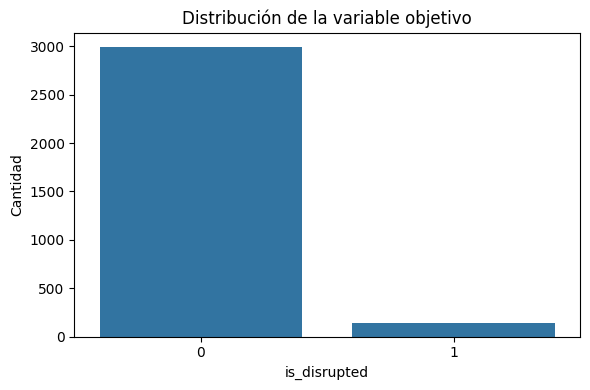

In [13]:
# Graficamos la variable objetivo
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_disrupted"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("is_disrupted")
plt.ylabel("Cantidad")
plt.tight_layout()

plt.savefig("../results/plots/is_disrupted_distribution.png")
plt.show()

La variable `is_disrupted` será usada en el modelo de clasificación. Si una clase aparece mucho más que la otra, después no conviene evaluar solo con accuracy, sino también con métricas como precision, recall y F1-score.

## 8. Selección de variables para clasificación

Se seleccionan variables que podrían ayudar a anticipar una disrupción. No se usan `rerouted` ni `flight_cancelled` como predictoras, porque esas columnas se usaron para crear la variable objetivo.

In [14]:
# Variable objetivo
target_classification = "is_disrupted"

# Variables numéricas para clasificación
numeric_features_clf = [
    "original_distance_km",
    "jet_fuel_usd_barrel",
    "base_ticket_price_usd",
    "estimated_passengers",
    "fuel_pct_of_cost"
]

# Variables categóricas para clasificación
categorical_features_clf = [
    "airline"
]

# Variables predictoras
features_clf = numeric_features_clf + categorical_features_clf

X_clf = df[features_clf]
y_clf = df[target_classification]

print(X_clf.shape)
print(y_clf.value_counts())

(3132, 6)
is_disrupted
0    2989
1     143
Name: count, dtype: int64


## 9. Separación de datos

Se separan los datos en entrenamiento y prueba. El conjunto de entrenamiento se usa para ajustar los modelos y el de prueba se reserva para evaluarlos.

In [15]:
# Separamos datos de entrenamiento y prueba
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(X_train_clf.shape)
print(X_test_clf.shape)

(2505, 6)
(627, 6)


## 10. Preprocesamiento

Se prepara el preprocesamiento de las variables. Las numéricas se escalan y las categóricas se convierten con OneHotEncoding.

In [16]:
# Preprocesamiento para clasificación
preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_clf)
    ]
)

## 11. Modelos base

Se entrenan tres modelos iniciales: regresión logística, árbol de decisión y random forest. La idea es comparar modelos simples antes de pasar a optimización.

In [17]:
# Modelos base de clasificación
classification_models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_clf),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor_clf),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_clf),
        ("model", RandomForestClassifier(random_state=42))
    ])
}

## 12. Entrenamiento de modelos

Se entrenan los modelos base usando los datos de entrenamiento.

In [18]:
# Entrenamos cada modelo
for name, model in classification_models.items():
    model.fit(X_train_clf, y_train_clf)
    print(f"{name} entrenado")

Logistic Regression entrenado
Decision Tree entrenado
Random Forest entrenado


## 13. Guardado de modelos de clasificación

Guardamos los modelos entrenados para usarlos después en la evaluación.

In [19]:
# Guardamos los modelos entrenados
for name, model in classification_models.items():
    filename = name.lower().replace(" ", "_") + "_classification_base.pkl"
    path = f"../models/trained_models/{filename}"
    joblib.dump(model, path)
    print(f"Guardado: {path}")

Guardado: ../models/trained_models/logistic_regression_classification_base.pkl
Guardado: ../models/trained_models/decision_tree_classification_base.pkl
Guardado: ../models/trained_models/random_forest_classification_base.pkl


## 14. Guardado de particiones

También se guardan los datos de entrenamiento y prueba. Así la evaluación usa exactamente la misma separación.

In [20]:
# Guardamos los datos usados en clasificación
classification_data = {
    "X_train": X_train_clf,
    "X_test": X_test_clf,
    "y_train": y_train_clf,
    "y_test": y_test_clf,
    "features": features_clf
}

joblib.dump(classification_data, "../results/metrics/classification_train_test_data.pkl")

['../results/metrics/classification_train_test_data.pkl']

## 15. Cierre del modelamiento base

En este notebook quedaron entrenados los modelos base de clasificación. También se guardaron los modelos y las particiones de datos para usarlos en la evaluación comparativa.